## Import the important libraries

In [9]:
import pandas as pd
import numpy as np
import re

# imports for data visualisation
import seaborn as sns
from PIL import Image
from scipy import stats
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
#from wordcloud import WordCloud, ImageColorGenerator
%matplotlib inline

# imports for pre-processing
import os
from nltk.tokenize import WordPunctTokenizer
from bs4 import BeautifulSoup
from collections import Counter
from nltk.corpus import wordnet
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tokenize import TweetTokenizer
from nltk.stem.porter import *
import string
import nltk

## Read in the data

In [10]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test_with_no_labels.csv")

# # Create a copy for EDA
# train_eda = df_train.copy()

# # Create copies for modeling
# train = df_train.copy()
# test = df_test.copy()

In [11]:
df_train.head()

,sentiment,message,tweetid
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221
1,1,It's not like we lack evidence of anthropogeni...,126103
2,2,RT @RawStory: Researchers say we have three ye...,698562
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954


In [12]:
df_test.head()

,message,tweetid
0,Europe will now be looking to China to make su...,169760
1,Combine this with the polling of staffers re c...,35326
2,"The scary, unimpeachable evidence that climate...",224985
3,@Karoli @morgfair @OsborneInk @dailykos \nPuti...,476263
4,RT @FakeWillMoore: 'Female orgasms cause globa...,872928


In [7]:
df_train.shape

(15819, 3)

In [8]:
df_test.shape

(10546, 2)

In [106]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15819 entries, 0 to 15818
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  15819 non-null  int64 
 1   message    15819 non-null  object
 2   tweetid    15819 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 370.9+ KB


Checking if there are missing values...


In [108]:
df_train.isnull().sum()

sentiment    0
message      0
tweetid      0
dtype: int64

There are no missing values in the train dataset.

## Pre-processing

First, we extract mentions and hashtags

In [13]:
def get_hashtags_and_mentions(df):
    df["hashtags"] = df["message"].str.lower().str.findall(r'#.*?(?=\s|$)')
    hashtags = df["hashtags"]
    
    df["mentions"] = df["message"].str.lower().str.findall(r'@\w*')
    mentions = df["mentions"]
    
    df["url"] = df["message"].str.lower().str.findall(r'http\S+|www.\S+')
    urls = df["url"]

    df["hashtags"] = [np.nan if len(x) == 0 else x for x in hashtags]
    df["mentions"] = [np.nan if len(x) == 0 else x for x in mentions]
    df["url"] = [np.nan if len(x) == 0 else x for x in urls]
    
    return df

In [14]:
get_hashtags_and_mentions(df_train).head()

,sentiment,message,tweetid,hashtags,mentions,url
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc]
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN
2,2,RT @RawStory: Researchers say we have three ye...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]"
3,1,#TodayinMaker# WIRED : 2016 was a pivotal year...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd]
4,1,"RT @SoyNovioDeTodas: It's 2016, and a racist, ...",466954,[#electionnight],[@soynoviodetodas],NaN


Second, we remove Twitter handles (e.g., @RawStory), hashtags, mentions and urls. These do not provide any important information related to our objective

In [15]:
def remove_urls(text):
    return re.sub(r'http\S+|www.\S+', '', text)

def remove_twitter_handles(text):
    return re.sub(r'@\w*', '', text)

def remove_hashtags(text):
    return re.sub(r'#.*?(?=\s|$)', '', text)

def remove_rt(text):
    return text.replace('RT', '')

df_train["message"] = df_train["message"].apply(remove_urls)
df_train["message"] = df_train["message"].apply(remove_twitter_handles)
df_train["message"] = df_train["message"].apply(remove_hashtags)
df_train["message"] = df_train["message"].apply(remove_rt)

df_train.head()

,sentiment,message,tweetid,hashtags,mentions,url
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc]
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]"
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd]
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN


## Tokenization

Tokenization is the process of tokenizing or splitting a string, text into a list of tokens. One can think of token as parts like a word is a token in a sentence, and a sentence is a token in a paragraph.
Now we will tokenize all the cleaned tweets in our dataset. Tokens are individual terms or words, and tokenization is the process of splitting a string of text into tokens.

During tokenization, we will also remove the following:
- Punctuation, special characters and numbers: With regards to punctuation, special characters and numbers, many, if not all, do not change or determine the overall sentiment of a tweet. Thus, it is important to remove these from the tweets.

- Short words (i.e., single letters): A vast majoity of short words which are only one letter long do not add much information surrounding the sentiment.

In [16]:
def tokenize_tweets(df):
    # tokenizing the tweets
    # Read more: https://www.kaggle.com/general/288653
    cleaned_tweets = df["message"].apply(TweetTokenizer().tokenize)

    # remove punctuation
    cleaned_tweets = cleaned_tweets.apply(lambda x : [token for token in x if token not in string.punctuation])

    # removing digits from the tweets
    cleaned_tweets = cleaned_tweets.apply(lambda x: [token for token in x if token not in list(string.digits)])

    # removing all one character tokens
    cleaned_tweets = cleaned_tweets.apply(lambda x: [token for token in x if len(token) > 1])
    
    df["tokenized_tweets"] = cleaned_tweets
    
    return df["tokenized_tweets"]

In [17]:
tokenize_tweets(df_train).head()

0    [PolySciMajor, EPA, chief, doesn't, think, car...
1    [It's, not, like, we, lack, evidence, of, anth...
2    [Researchers, say, we, have, three, years, to,...
3    [WIRED, 2016, was, pivotal, year, in, the, war...
4    [It's, 2016, and, racist, sexist, climate, cha...
Name: tokenized_tweets, dtype: object

# Stopwords

Stop words are commonly occurring words that are often considered to be insignificant and are typically removed from text during preprocessing. These words include articles (e.g., "a," "an," "the"), prepositions (e.g., "in," "on," "at"), conjunctions (e.g., "and," "but," "or"), and other high-frequency words that do not carry substantial meaning or contribute significantly to the context of the text.

The rationale behind removing stop words is to reduce the dimensionality of the data and eliminate noise that may interfere with certain NLP tasks, such as text classification, information retrieval, and sentiment analysis. By removing these frequently occurring words, we can focus on the more informative and content-rich words that are likely to carry more significance in the analysis.

In [18]:
nltk.download('stopwords')

stop = stopwords.words('english')

# Convert to lower case
df_train["tokenized_tweets"] = df_train["tokenized_tweets"].apply(lambda x: [word.lower() for word in x])

# Remove stopwords
df_train["no_stopwords"] = df_train["tokenized_tweets"].apply(lambda x: [item for item in x if item not in stop])

df_train.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\esthe\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox..."
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ..."
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,..."
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha..."
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin..."


# Stemming

In [19]:
from nltk import SnowballStemmer, PorterStemmer, LancasterStemmer

In [20]:
stemmer = SnowballStemmer('english')

In [21]:
def tweets_stemmer(words, stemmer):
    return [stemmer.stem(word) for word in words]

In [24]:
df_train['stem'] = df_train['no_stopwords'].apply(tweets_stemmer, args=(stemmer, ))

In [36]:
df_train.head()

,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,stem
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox...","[polyscimajor, epa, chief, think, carbon, diox..."
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ...","[like, lack, evid, anthropogen, global, warm]"
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,...","[research, say, three, year, act, climat, chan..."
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha...","[wire, 2016, pivot, year, war, climat, chang]"
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin...","[2016, racist, sexist, climat, chang, deni, bi..."


# Lemmantization

In [26]:
###Lemma not lemming, hence Ive commented out this section###

# from nltk.stem import WordNetLemmatizer
# nltk.download('wordnet')

# lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\esthe\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [30]:
# def tweets_lemma(words, lemmatizer):
#     return [lemmatizer.lemmatize(word) for word in words]

In [31]:
# df_train['lemma'] = df_train['no_stopwords'].apply(tweets_lemma, args=(lemmatizer, ))

In [35]:
# df_train.head()
# df_train = df_train.drop(['lemma'], axis = 1)

The words `climatechange`, `climate` and `change`, do not serve a purpose in this case since all tweets should have at least one of them. So we remove them

In [37]:
# remove_words = ["climatechange", "climate", "change"]
# df_train["no_climate"] = [[a for a in word if not a in remove_words] for word in df_train["no_stopwords"]]

# df_train.head()

Create a column for each tweets sentiment

In [38]:
# df_train["sentiment_name"] = df_train["sentiment"].map({-1: "Anti", 0: "Neutral", 1: "Pro", 2: "News"})
# df_train.head()

# Exploratory data analysis

In [39]:
df_eda = df_train.copy()
df_eda.head()

,sentiment,message,tweetid,hashtags,mentions,url,tokenized_tweets,no_stopwords,stem
0,1,PolySciMajor EPA chief doesn't think carbon di...,625221,NaN,[@mashable],[https://t.co/yelvcefxkc],"[polyscimajor, epa, chief, doesn't, think, car...","[polyscimajor, epa, chief, think, carbon, diox...","[polyscimajor, epa, chief, think, carbon, diox..."
1,1,It's not like we lack evidence of anthropogeni...,126103,NaN,NaN,NaN,"[it's, not, like, we, lack, evidence, of, anth...","[like, lack, evidence, anthropogenic, global, ...","[like, lack, evid, anthropogen, global, warm]"
2,2,: Researchers say we have three years to act ...,698562,NaN,[@rawstory],"[https://t.co/wdt0kdur2f, https://t.co/z0anpt…]","[researchers, say, we, have, three, years, to,...","[researchers, say, three, years, act, climate,...","[research, say, three, year, act, climat, chan..."
3,1,WIRED : 2016 was a pivotal year in the war on...,573736,[#todayinmaker#],NaN,[https://t.co/44wotxtlcd],"[wired, 2016, was, pivotal, year, in, the, war...","[wired, 2016, pivotal, year, war, climate, cha...","[wire, 2016, pivot, year, war, climat, chang]"
4,1,": It's 2016, and a racist, sexist, climate ch...",466954,[#electionnight],[@soynoviodetodas],NaN,"[it's, 2016, and, racist, sexist, climate, cha...","[2016, racist, sexist, climate, change, denyin...","[2016, racist, sexist, climat, chang, deni, bi..."


In [59]:
sentiment_map = {
    -1: "Anti",
     0: "Neutral",
     1: "Pro",
     2: "News",
}
df_eda["sentiment"] = df_eda["sentiment"].apply(lambda num: sentiment_map[num])
df_eda.head()

KeyError: 'Pro'

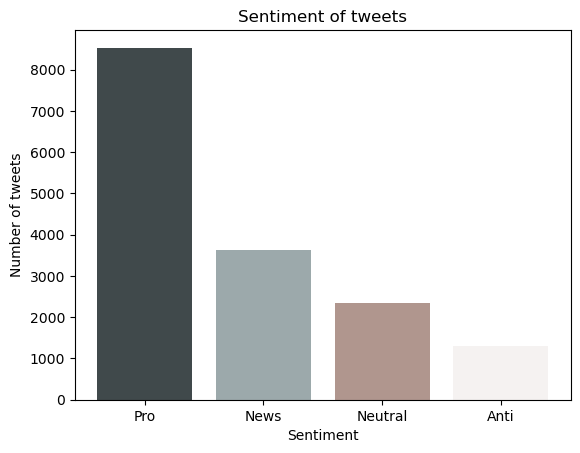

In [52]:
colors = ['#40494b', '#9ca9ab','#b0968e','#f5f2f1']  # Specify colors for each bar

plt.bar(df_eda['sentiment'].unique(), df_eda['sentiment'].value_counts(), color=colors)

# Add labels and title
plt.xlabel('Sentiment')
plt.ylabel('Number of tweets')
plt.title('Sentiment of tweets')

# Display the plot
plt.show()

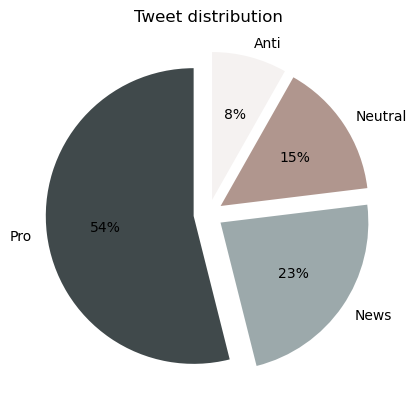

In [55]:
labels = df_eda['sentiment'].unique()

plt.pie(df_eda["sentiment"].value_counts(),
            labels=labels,
            autopct="%1.0f%%",
            startangle=90,
            colors = colors,
            explode=tuple([0.1] * len(labels)))

plt.title('Tweet distribution')

# Display the plot
plt.show()

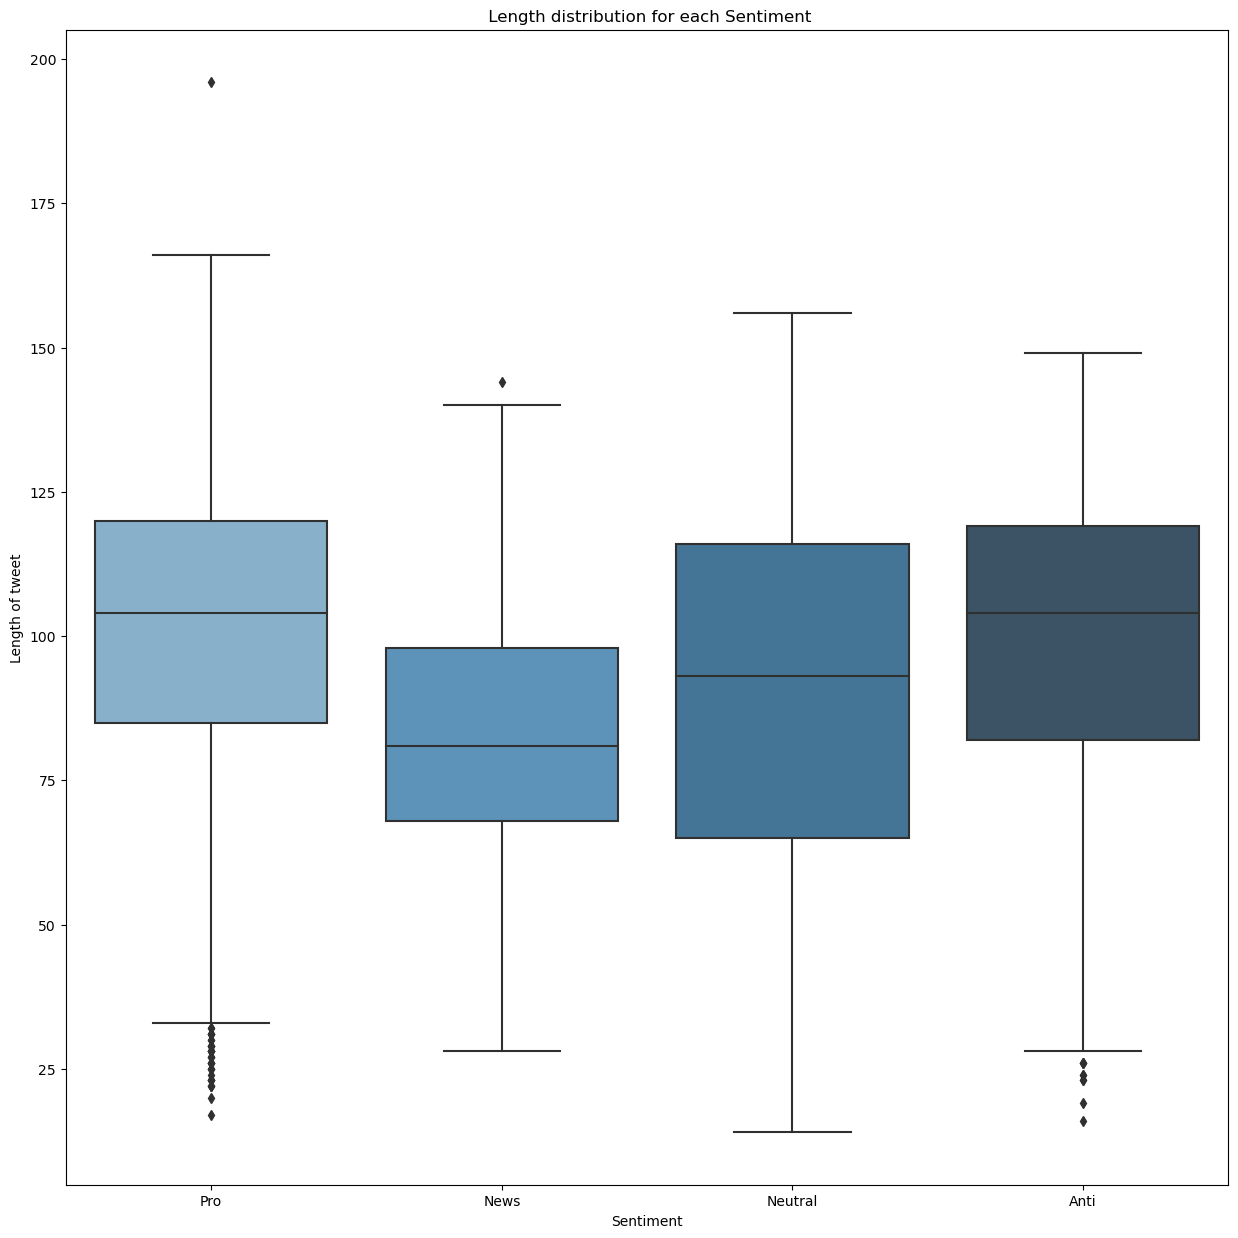

In [61]:
plt.figure(figsize=(15, 15))
sns.boxplot(x="sentiment", y=df_eda['message'].apply(len), data=df_eda, palette=("Blues_d"))
plt.title(" Length distribution for each Sentiment")

# Adding labels 
plt.xlabel('Sentiment')
plt.ylabel('Length of tweet')

plt.show()

#Still yet to do descriptive stats on of sentiment classes and hist distributions

In [73]:
#Top 10 hashtags used in each class
from tqdm.auto import tqdm
import itertools
import re

top10 = {}

by_sentiment = df_eda.groupby("sentiment")
for sentiment, group in tqdm(by_sentiment):
    hashtags = group["hashtags"].apply(lambda tweet: re.findall(r'#.*?(?=\s|$)', str(tweet)))
    hashtags = itertools.chain(*hashtags)
    hashtags = [ht.lower() for ht in hashtags]
    
    frequency = nltk.FreqDist(hashtags)
    
    df_hashtags = pd.DataFrame({
        "hashtags": list(frequency.keys()),
        "count": list(frequency.values()),
    })
    top10_htags = df_hashtags.nlargest(10, columns=["count"])
    
    top10[sentiment] = top10_htags.reset_index(drop=True)

display(pd.concat(top10, axis=1).head(n=10))

  0%|          | 0/4 [00:00<?, ?it/s]

Anti                  Neutral                       News  \
            hashtags count           hashtags count             hashtags   
0            #maga']    10   #climatechange']    11           #climate']   
1         #climate']    10         #climate']    11           #climate',   
2           #trump']     6           #trump']     8     #climatechange']   
3   #climatechange',     5         #climate',     7       #environment']   
4            #tcot',     4   #climatechange',     4     #climatechange',   
5  #parisagreement']     4       #amreading']     4              #news']   
6   #globalwarming',     4           #cop22']     4              #news',   
7        #fakenews']     3  #beforetheflood']     4  #greatbarrierreef']   
8            #maga',     3     #parisaccord']     3       #environment',   
9    #opchemtrails']     3           #trump',     3             #trump']   

                        Pro        
  count            hashtags count  
0    72   #beforetheflood']   133  
1    60          #climate']   110  
2    43          #climate',    74  
3    33  #imvotingbecause']    61  
4    18    #climatechange']    61  
5    17    #climatechange',    43  
6    14          #ã¢â‚¬â¦']    37  
7    12    #ivotedbecause',    33  
8    12   #parisagreement']    32  
9    11            #cop22']    27

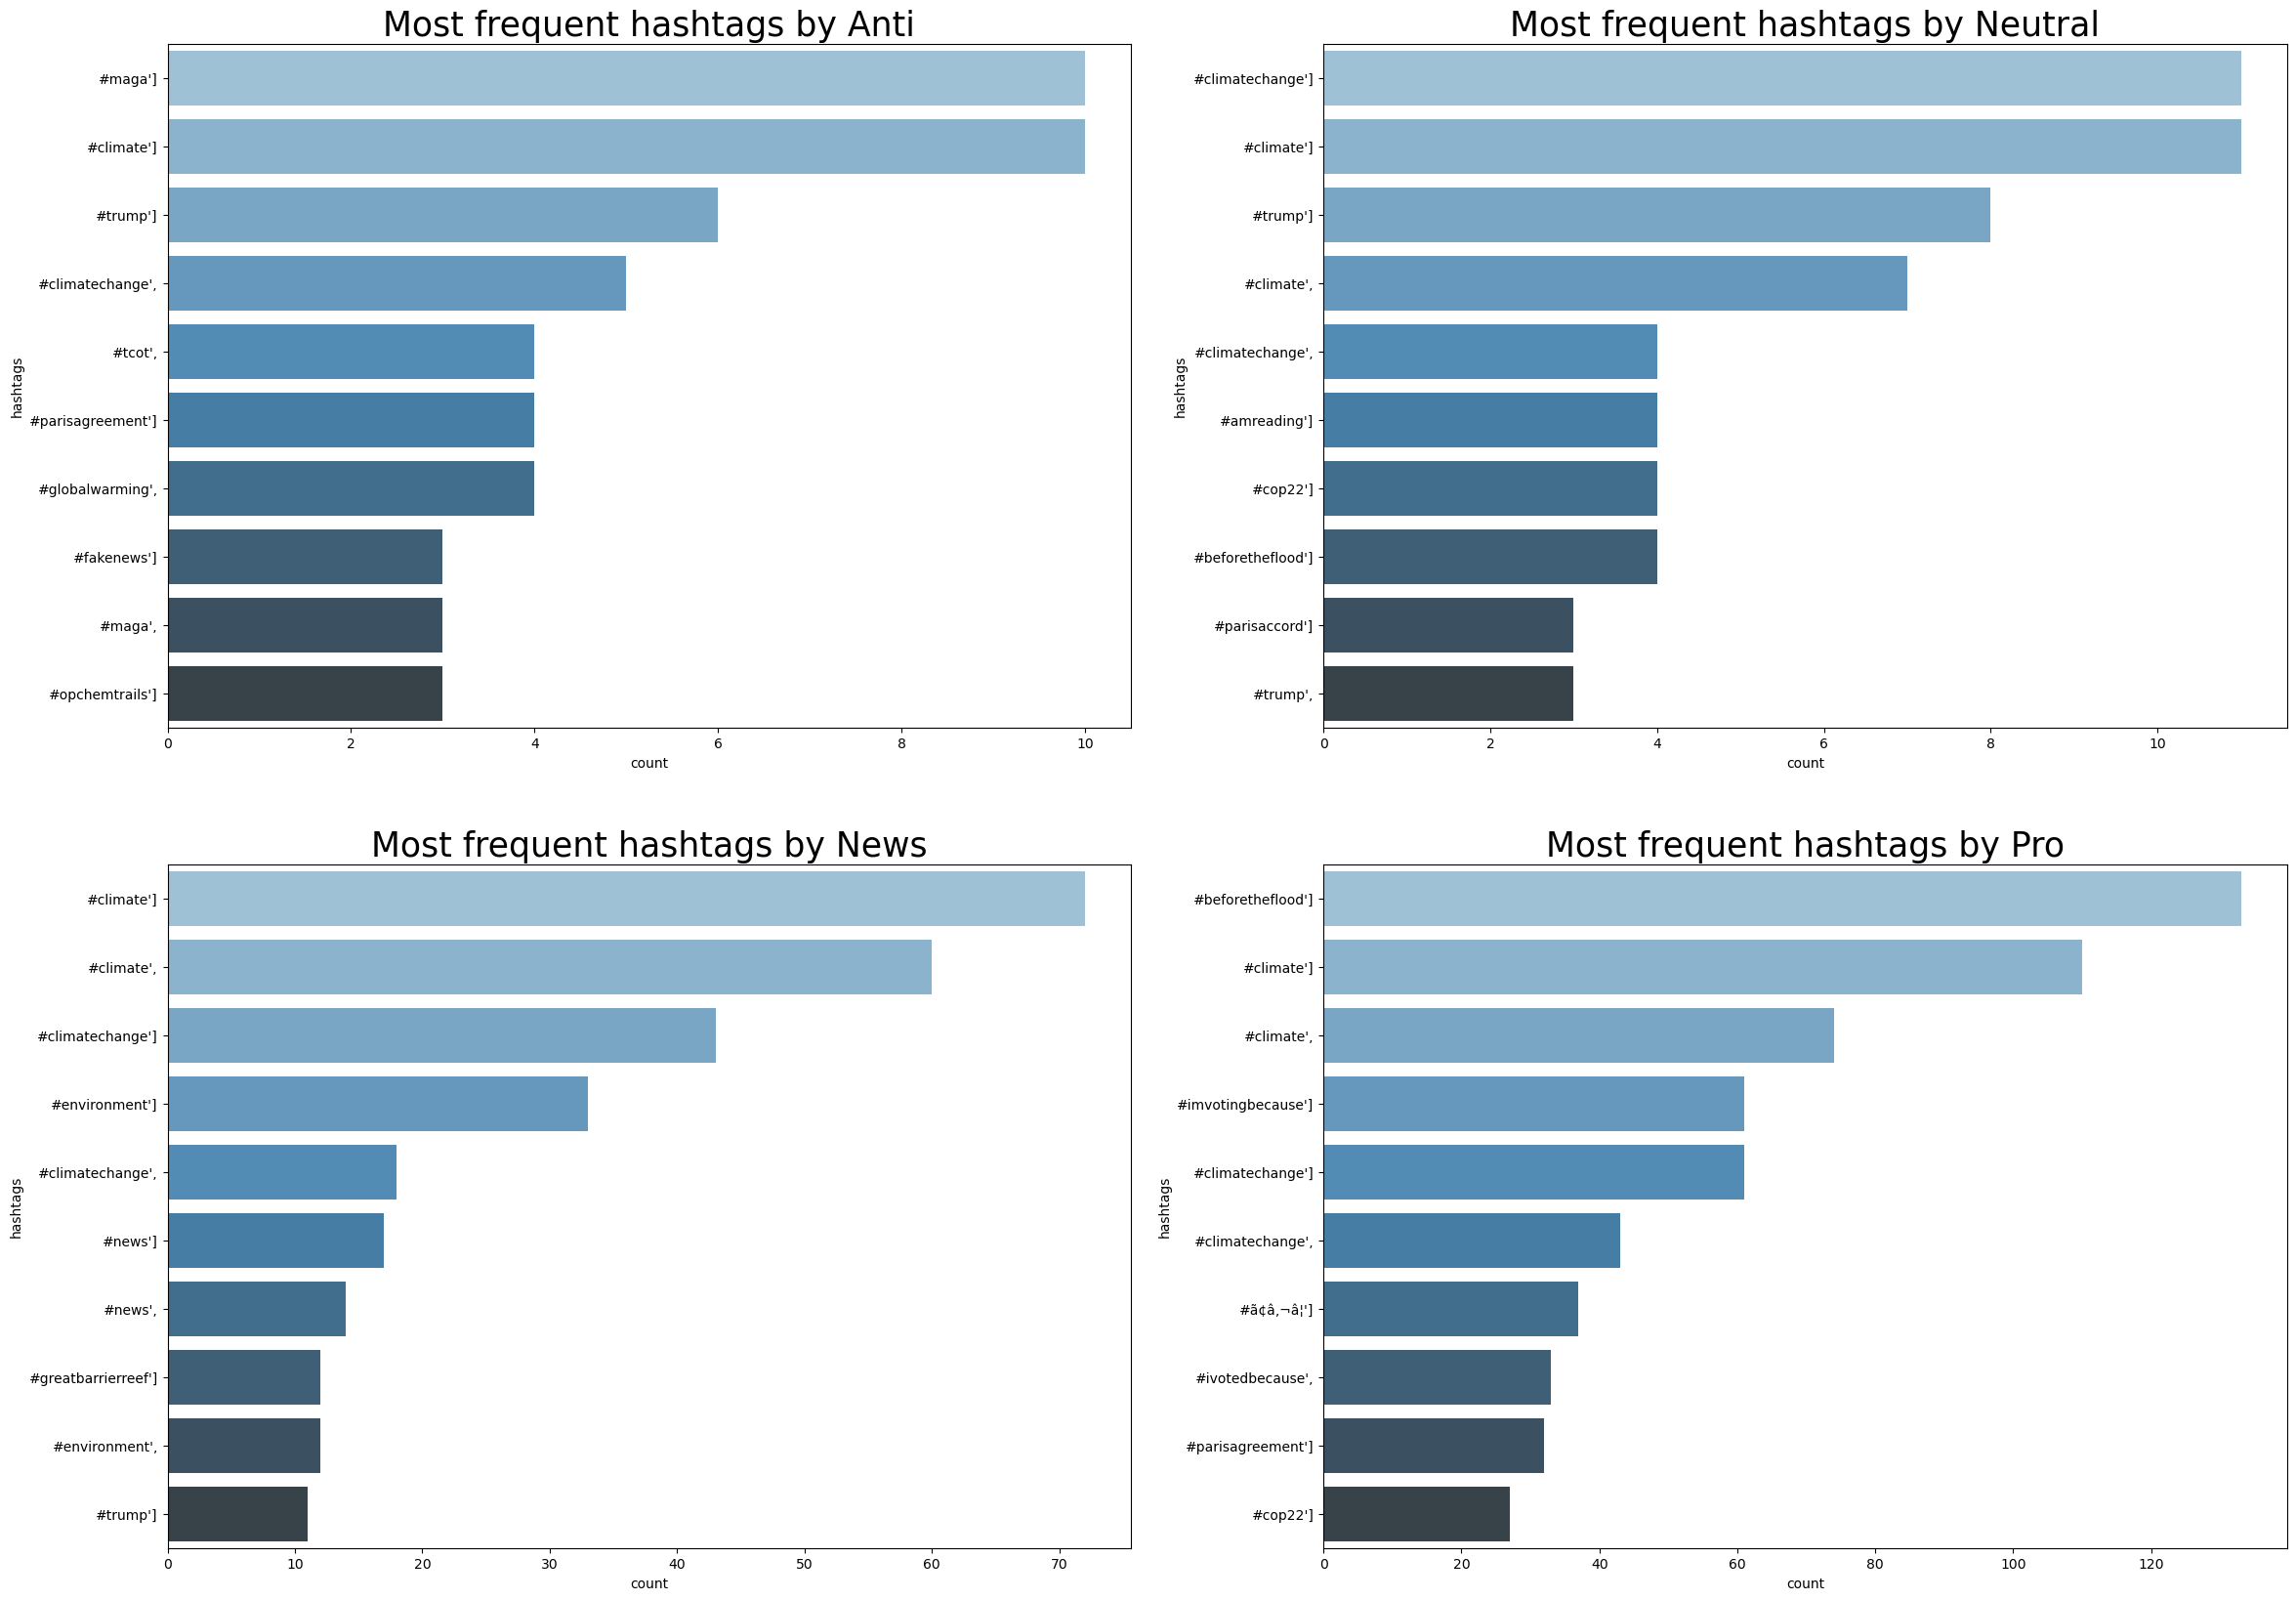

In [75]:
#Visuals of top 10 tweets
fig, axes = plt.subplots(2, 2, figsize=(28, 20))
counter = 0

for sentiment, top in top10.items():
    sns.barplot(data=top, y="hashtags", x="count", palette="Blues_d", ax=axes[counter // 2, counter % 2])
    axes[counter // 2, counter % 2].set_title(f"Most frequent hashtags by {sentiment}", fontsize=25)
    counter += 1
plt.show()

# Modelling

In [82]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
X = df_train["stem"]
y = df_train["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

In [83]:
#Applying logistic regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()


In [86]:
#lr.fit(X_train, y_train)

<!-- Separate dataframes of tweets for each sentiment -->

In [46]:
# # Anti tweets
# anti_df = df_train[df_train["sentiment"] == -1]
# anti_df.head()

In [45]:
# # Neutral tweets
# neutral_df = df_train[df_train["sentiment"] == 0]
# neutral_df.head()

In [44]:
# # Pro tweets
# pro_df = df_train[df_train["sentiment"] == 1]
# pro_df.head()

In [43]:
# # News tweets
# news_df = df_train[df_train["sentiment"] == 2]
# news_df.head()